In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta
import matplotlib.ticker as mtick


In [2]:
raw_data = pd.read_csv("../data/raw_data_all_locations.csv")
raw_data

,Date,Bird,Time,LeftPecks,RightPecks,LeftSeed,RightSeed,source_sheet,Notes,CoolDown
0,2025-10-05,Great tit,12:56:00,NaN,NaN,NaN,NaN,southampton_uk,NaN,NaN
1,2025-10-05,Great tit,16:58:00,NaN,NaN,NaN,NaN,southampton_uk,NaN,NaN
2,2025-10-06,Great tit,09:17:00,NaN,NaN,NaN,NaN,southampton_uk,NaN,NaN
3,2025-10-06,Great tit,11:59:00,NaN,NaN,NaN,NaN,southampton_uk,NaN,NaN
4,2025-10-06,Great tit,14:15:00,NaN,NaN,NaN,NaN,southampton_uk,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...
48908,2026-01-18,Northern Cardinal,16:19:00,NaN,NaN,Mix,Mix,essex_fells_nj_07021,NaN,1 min
48909,2026-01-18,Northern Cardinal,16:20:00,NaN,NaN,Mix,Mix,essex_fells_nj_07021,NaN,1 min
48910,2026-01-18,Northern Cardinal,16:22:00,NaN,NaN,Mix,Mix,essex_fells_nj_07021,NaN,1 min
48911,2026-01-18,Northern Cardinal,16:23:00,NaN,NaN,Mix,Mix,essex_fells_nj_07021,NaN,1 min


## Proportion of visits with peck switches

In [14]:
peck_data = raw_data.dropna(subset=['LeftPecks', 'RightPecks'])[['Date', 'Bird', 'Time', 'LeftPecks', 'RightPecks']].reset_index(drop=True)
peck_both = []

for i in range(len(peck_data)):
    left = peck_data.loc[i, 'LeftPecks'] > 0
    right = peck_data.loc[i, 'RightPecks'] > 0
    if left and right:
        peck_both.append(1)
    else:
        peck_both.append(0)
peck_data['peck_both'] = peck_both
peck_both = pd.DataFrame(peck_data.groupby('Bird')['peck_both'].sum()).reset_index()
count_df = peck_data.value_counts('Bird').reset_index()
count_dict = dict(zip(count_df['Bird'], count_df['count']))

peck_both['count'] = peck_both['Bird'].map(count_dict)
peck_both['proportion'] = peck_both['peck_both'] / peck_both['count']
peck_both.sort_values('proportion', ascending=False, inplace=True)
peck_both.reset_index(drop=True, inplace=True)

peck_both

,Bird,peck_both,count,proportion
0,Common Ground Dove,5,22,0.227273
1,Pine Warbler,8,55,0.145455
2,Carolina Wren,88,743,0.118439
3,Eastern Bluebird,43,523,0.082218
4,Mourning Dove,263,4445,0.059168
5,Red-bellied Woodpecker,9,206,0.043689
6,Northern Cardinal,124,2951,0.042020
7,Tufted Titmouse,24,1269,0.018913
8,Carolina Chickadee,9,928,0.009698
9,Gray Catbird,0,1,0.000000


In [17]:
time_sampling = raw_data[['Date', 'Time', 'Bird', 'source_sheet']]
time_sampling

,Date,Time,Bird,source_sheet
0,2025-10-05,12:56:00,Great tit,southampton_uk
1,2025-10-05,16:58:00,Great tit,southampton_uk
2,2025-10-06,09:17:00,Great tit,southampton_uk
3,2025-10-06,11:59:00,Great tit,southampton_uk
4,2025-10-06,14:15:00,Great tit,southampton_uk
...,...,...,...,...
48908,2026-01-18,16:19:00,Northern Cardinal,essex_fells_nj_07021
48909,2026-01-18,16:20:00,Northern Cardinal,essex_fells_nj_07021
48910,2026-01-18,16:22:00,Northern Cardinal,essex_fells_nj_07021
48911,2026-01-18,16:23:00,Northern Cardinal,essex_fells_nj_07021


In [20]:
import numpy as np
import pandas as pd

from dataclasses import dataclass
from typing import Tuple, List


# ============================================================
# Config
# ============================================================

@dataclass(frozen=True)
class SamplingConfig:
    # Sampling effort
    window_minutes: int = 10          # length of each sampling window (bin size)
    windows_per_day: int = 1          # number of bins/day to sample

    # Randomness
    seed: int = 13126

    # Evaluation
    min_days_required: int = 7        # skip site if not enough days

    # Random strategy stability (optional)
    random_repeats: int = 1           # >1 = repeat random sampling and average metrics per site/setting


# ============================================================
# Preprocess
# ============================================================

def prepare_df(raw: pd.DataFrame) -> pd.DataFrame:
    """
    Robust parsing:
    - Coerce Date/Time parsing errors to NaT and drop invalid rows.
    - Create minute_of_day as int [0..1439].
    """
    df = raw.copy()

    df["Date"] = pd.to_datetime(df["Date"], errors="coerce").dt.date

    # robust time parsing
    t = pd.to_datetime(df["Time"].astype(str), errors="coerce")
    df["minute_of_day"] = t.dt.hour * 60 + t.dt.minute

    df["Bird"] = df["Bird"].astype(str).str.strip()
    df["source_sheet"] = df["source_sheet"].astype(str).str.strip()

    # drop rows we cannot place in time
    df = df.dropna(subset=["Date", "minute_of_day", "Bird", "source_sheet"]).copy()
    df["minute_of_day"] = df["minute_of_day"].astype(int)

    return df


def add_time_bins(df: pd.DataFrame, cfg: SamplingConfig) -> pd.DataFrame:
    """
    Convert event times into bins of size cfg.window_minutes.
    IMPORTANT: availability is ONLY bins that have events (BirdFy is event-triggered).
    """
    out = df.copy()
    bin_minutes = cfg.window_minutes

    out["bin"] = (out["minute_of_day"] // bin_minutes).astype(int)
    out["bin_start_minute"] = (out["bin"] * bin_minutes).astype(int)
    return out


def build_bin_panel(df_site: pd.DataFrame, cfg: SamplingConfig) -> pd.DataFrame:
    """
    Returns bin-level counts per species for each day, using ONLY bins that contain >=1 event.
    Index columns: Date, bin
    Value columns: species counts (wide)
    Also includes total detections per bin and bin_start_minute.
    """
    # counts per (Date, bin, Bird)
    c = (
        df_site.groupby(["Date", "bin", "Bird"])
        .size()
        .rename("count")
        .reset_index()
    )

    # wide species matrix at bin resolution
    wide = (
        c.pivot_table(index=["Date", "bin"], columns="Bird", values="count", aggfunc="sum", fill_value=0)
        .reset_index()
    )

    # total detections per bin
    species_cols = [col for col in wide.columns if col not in ("Date", "bin")]
    wide["total_detections"] = wide[species_cols].sum(axis=1)

    # convenience: start minute of bin
    wide["bin_start_minute"] = (wide["bin"] * cfg.window_minutes).astype(int)

    return wide


# ============================================================
# Sampling strategies (BIN-BASED)
# ============================================================

def sample_fixed_time(panel: pd.DataFrame, cfg: SamplingConfig, start_minute: int) -> pd.DataFrame:
    """
    BIN-BASED fixed time:
    - Choose the same start_minute bin each day (and then subsequent bins if windows_per_day>1).
    - If a chosen bin doesn't exist that day (no events in that bin), it contributes nothing.
    """
    bin_minutes = cfg.window_minutes
    start_bin = start_minute // bin_minutes

    sel = []
    for d, g in panel.groupby("Date", sort=False):
        available_bins = set(g["bin"].tolist())

        chosen_bins = []
        for k in range(cfg.windows_per_day):
            b = start_bin + k  # systematic adjacent bins
            if b in available_bins:
                chosen_bins.append(b)

        if chosen_bins:
            sel.append(g[g["bin"].isin(chosen_bins)].assign(sampled=1))

    out = pd.concat(sel, ignore_index=True) if sel else panel.head(0).assign(sampled=1)
    return out


def sample_random_time(panel: pd.DataFrame, cfg: SamplingConfig, seed: int | None = None) -> pd.DataFrame:
    """
    BIN-BASED random time:
    - For each day, choose windows_per_day random bins among bins that exist that day.
    """
    rng = np.random.default_rng(cfg.seed if seed is None else seed)
    sel = []

    for d, g in panel.groupby("Date", sort=False):
        bins = g["bin"].unique()
        if len(bins) == 0:
            continue

        k = min(cfg.windows_per_day, len(bins))
        chosen = rng.choice(bins, size=k, replace=False)
        sel.append(g[g["bin"].isin(chosen)].assign(sampled=1))

    out = pd.concat(sel, ignore_index=True) if sel else panel.head(0).assign(sampled=1)
    return out


# ============================================================
# Truth + metrics
# ============================================================

def daily_truth_from_panel(panel: pd.DataFrame) -> Tuple[pd.DataFrame, List[str]]:
    species_cols = [c for c in panel.columns if c not in ("Date", "bin", "bin_start_minute", "total_detections")]
    truth = (
        panel.groupby("Date")[species_cols + ["total_detections"]]
        .sum()
        .reset_index()
    )
    truth["species_richness"] = (truth[species_cols] > 0).sum(axis=1)
    return truth, species_cols


def jaccard_presence(a: np.ndarray, b: np.ndarray) -> float:
    inter = np.logical_and(a, b).sum()
    union = np.logical_or(a, b).sum()
    return float(inter / union) if union > 0 else 1.0


def bray_curtis(a: np.ndarray, b: np.ndarray) -> float:
    denom = (a + b).sum()
    num = np.abs(a - b).sum()
    return float(1 - (num / denom)) if denom > 0 else 1.0


def evaluate_strategy(panel_full: pd.DataFrame, sample_panel: pd.DataFrame, cfg: SamplingConfig) -> pd.DataFrame:
    """
    Evaluate sampled bins against full bin-truth.
    NOTE: Effort is measured in BINS (not minutes), since availability is "bins with events".
    """
    truth, species_cols = daily_truth_from_panel(panel_full)

    sampled = (
        sample_panel.groupby("Date")[species_cols + ["total_detections"]]
        .sum()
        .reset_index()
    )
    sampled["species_richness"] = (sampled[species_cols] > 0).sum(axis=1)

    # bins available vs sampled (effort)
    avail = panel_full.groupby("Date")["bin"].nunique().rename("bins_available").reset_index()
    bins_s = sample_panel.groupby("Date")["bin"].nunique().rename("bins_sampled").reset_index()

    scored = truth.merge(sampled, on="Date", how="left", suffixes=("_true", "_samp")).fillna(0)
    scored = scored.merge(avail, on="Date", how="left").merge(bins_s, on="Date", how="left").fillna({"bins_sampled": 0})

    scored["sampling_fraction"] = scored["bins_sampled"] / scored["bins_available"].replace(0, np.nan)

    # Errors
    scored["total_abs_err"] = (scored["total_detections_samp"] - scored["total_detections_true"]).abs()
    scored["total_ape"] = np.where(
        scored["total_detections_true"] > 0,
        scored["total_abs_err"] / scored["total_detections_true"],
        np.nan
    )
    scored["richness_abs_err"] = (scored["species_richness_samp"] - scored["species_richness_true"]).abs()

    # Community similarity per day
    sims = []
    for _, row in scored.iterrows():
        a_counts = row[[f"{c}_true" for c in species_cols]].to_numpy(dtype=float)
        b_counts = row[[f"{c}_samp" for c in species_cols]].to_numpy(dtype=float)
        a_pres = a_counts > 0
        b_pres = b_counts > 0
        sims.append({
            "Date": row["Date"],
            "jaccard": jaccard_presence(a_pres, b_pres),
            "bray_curtis": bray_curtis(a_counts, b_counts),
        })
    sims = pd.DataFrame(sims)
    scored = scored.merge(sims, on="Date", how="left")

    # Aggregate summary
    summary = pd.DataFrame([{
        "days": int(scored.shape[0]),
        "bins_available_mean": float(scored["bins_available"].mean()),
        "bins_sampled_mean": float(scored["bins_sampled"].mean()),
        "sampling_fraction_mean": float(scored["sampling_fraction"].mean()),
        "total_MAE": float(scored["total_abs_err"].mean()),
        "total_MAPE": float(scored["total_ape"].mean(skipna=True)),
        "richness_MAE": float(scored["richness_abs_err"].mean()),
        "jaccard_mean": float(scored["jaccard"].mean()),
        "bray_curtis_mean": float(scored["bray_curtis"].mean()),
    }])

    return summary


# ============================================================
# Grid search per site
# ============================================================

def grid_search_site(df: pd.DataFrame, site: str, cfg: SamplingConfig,
                     fixed_start_minutes: List[int]) -> pd.DataFrame:
    """
    For one site:
    - builds bin-panel (event bins only)
    - evaluates fixed-time (bin) starts
    - evaluates random-time (bin) strategy (optionally repeated for stability)
    """
    df_site = df[df["source_sheet"] == site].copy()
    if df_site["Date"].nunique() < cfg.min_days_required:
        return pd.DataFrame()

    # add bins and build bin panel
    df_site = add_time_bins(df_site, cfg)
    panel = build_bin_panel(df_site, cfg)

    results = []

    # Fixed-time variants
    for start in fixed_start_minutes:
        samp = sample_fixed_time(panel, cfg, start_minute=start)
        s = evaluate_strategy(panel, samp, cfg)
        s["site"] = site
        s["strategy"] = "fixed_time_bins"
        s["start_minute"] = start
        results.append(s)

    # Random-time variants (repeat for stability if desired)
    reps = max(1, int(cfg.random_repeats))
    random_rows = []
    for r in range(reps):
        samp = sample_random_time(panel, cfg, seed=cfg.seed + r)
        s = evaluate_strategy(panel, samp, cfg)
        random_rows.append(s)

    s_rand = pd.concat(random_rows, ignore_index=True).mean(numeric_only=True).to_frame().T
    s_rand["site"] = site
    s_rand["strategy"] = "random_time_bins"
    s_rand["start_minute"] = np.nan
    results.append(s_rand)

    return pd.concat(results, ignore_index=True) if results else pd.DataFrame()

In [21]:
df = prepare_df(time_sampling)

cfg = SamplingConfig(
    window_minutes=10,
    windows_per_day=1,
    seed=13126,
    min_days_required=7,
    random_repeats=25,   # optional; 1 is fine to start
)

fixed_starts = [h * 60 for h in range(0, 24)]  # 00:00..23:00

all_sites = df["source_sheet"].unique().tolist()
out = []
for site in all_sites:
    out.append(grid_search_site(df, site, cfg, fixed_start_minutes=fixed_starts))

results = pd.concat(out, ignore_index=True)
results


/var/folders/c5/vpx80swj4yb9ytlnrk8w2qnr0000gn/T/ipykernel_94376/2381692264.py:43: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  t = pd.to_datetime(df["Time"].astype(str), errors="coerce")


,days,bins_available_mean,bins_sampled_mean,sampling_fraction_mean,total_MAE,total_MAPE,richness_MAE,jaccard_mean,bray_curtis_mean,site,strategy,start_minute
0,91.0,37.164835,0.010989,0.000172,224.461538,0.999964,4.901099,0.001832,0.000071,southampton_uk,fixed_time_bins,0.0
1,91.0,37.164835,0.000000,0.000000,224.472527,1.000000,4.912088,0.000000,0.000000,southampton_uk,fixed_time_bins,60.0
2,91.0,37.164835,0.000000,0.000000,224.472527,1.000000,4.912088,0.000000,0.000000,southampton_uk,fixed_time_bins,120.0
3,91.0,37.164835,0.000000,0.000000,224.472527,1.000000,4.912088,0.000000,0.000000,southampton_uk,fixed_time_bins,180.0
4,91.0,37.164835,0.010989,0.000183,224.461538,0.999971,4.901099,0.001832,0.000058,southampton_uk,fixed_time_bins,240.0
...,...,...,...,...,...,...,...,...,...,...,...,...
70,91.0,28.769231,0.000000,0.000000,189.142857,1.000000,5.461538,0.000000,0.000000,essex_fells_nj_07021,fixed_time_bins,1200.0
71,91.0,28.769231,0.000000,0.000000,189.142857,1.000000,5.461538,0.000000,0.000000,essex_fells_nj_07021,fixed_time_bins,1260.0
72,91.0,28.769231,0.000000,0.000000,189.142857,1.000000,5.461538,0.000000,0.000000,essex_fells_nj_07021,fixed_time_bins,1320.0
73,91.0,28.769231,0.000000,0.000000,189.142857,1.000000,5.461538,0.000000,0.000000,essex_fells_nj_07021,fixed_time_bins,1380.0


In [27]:
# ============================================================
# Pareto utilities
# ============================================================

def pareto_front(df: pd.DataFrame,
                 effort_col: str,
                 score_cols: list[str],
                 maximize: list[bool]) -> pd.DataFrame:
    """
    Return non-dominated rows.

    A row A dominates B if:
      - A is <= B on effort (always minimize effort)
      - and for every score col:
           if maximize[i] True:  A >= B
           else:                 A <= B
      - and at least one strict inequality holds across (effort + scores)

    This is O(n^2) but fine for modest grids.
    """
    if df.empty:
        return df

    X = df[[effort_col] + score_cols].to_numpy(dtype=float)

    # transform to "minimize all dims" by flipping maximize dims
    # effort already minimize
    X2 = X.copy()
    for j, mx in enumerate(maximize, start=1):  # score dims start at col 1
        if mx:
            X2[:, j] = -X2[:, j]  # maximize -> minimize

    n = X2.shape[0]
    is_dominated = np.zeros(n, dtype=bool)

    for i in range(n):
        if is_dominated[i]:
            continue
        for k in range(n):
            if i == k or is_dominated[i]:
                continue
            # k dominates i if all <= and any <
            if np.all(X2[k] <= X2[i]) and np.any(X2[k] < X2[i]):
                is_dominated[i] = True

    return df.loc[~is_dominated].copy()


# ============================================================
# Systematic reduction curve (per site)
# ============================================================

import numpy as np
import pandas as pd

def run_reduction_grid_all_k(
    df: pd.DataFrame,
    sites: list[str],
    window_minutes_grid: list[int],
    cfg_base,
    pareto_metric_primary: str = "bray_curtis_mean",
    pareto_metric_secondary: str = "jaccard_mean",
    max_windows_cap: int | None = None,   # optional safety cap if you want it
) -> tuple[pd.DataFrame, pd.DataFrame]:
    """
    For each site and each window_minutes:
      - compute max available bins/day (event bins) at that bin width
      - evaluate windows_per_day = 1..max_bins (optionally capped)
      - evaluate fixed-time starts at resolution window_minutes (all possible start bins)
      - evaluate random-time with cfg.random_repeats

    Returns (all_results, pareto_results) as before.
    """
    all_rows = []

    for site in sites:
        df_site = df[df["source_sheet"] == site].copy()
        if df_site["Date"].nunique() < cfg_base.min_days_required:
            continue

        for wm in window_minutes_grid:
            # Create a cfg for this bin width (windows_per_day set later)
            cfg_wm = cfg_base.__class__(
                window_minutes=wm,
                windows_per_day=1,  # placeholder; overridden in loop
                seed=cfg_base.seed,
                min_days_required=cfg_base.min_days_required,
                random_repeats=cfg_base.random_repeats,
            )

            # Build bin panel to learn feasibility for this (site, wm)
            df_site_b = add_time_bins(df_site, cfg_wm)
            panel = build_bin_panel(df_site_b, cfg_wm)

            if panel.empty:
                continue

            # max available bins in any day for this site at this bin width
            max_bins = int(panel.groupby("Date")["bin"].nunique().max())
            if max_bins < 1:
                continue

            if max_windows_cap is not None:
                max_bins = min(max_bins, int(max_windows_cap))

            # All possible fixed start times at this bin resolution
            fixed_starts = list(range(0, 1440, wm))

            # Loop k = 1..max_bins
            for k in range(1, max_bins + 1):
                cfg = cfg_base.__class__(
                    window_minutes=wm,
                    windows_per_day=k,
                    seed=cfg_base.seed,
                    min_days_required=cfg_base.min_days_required,
                    random_repeats=cfg_base.random_repeats,
                )

                # Reuse your existing per-site evaluation function
                res = grid_search_site(
                    df=df,
                    site=site,
                    cfg=cfg,
                    fixed_start_minutes=fixed_starts
                )

                if res.empty:
                    continue

                res["window_minutes"] = wm
                res["windows_per_day"] = k
                res["max_bins_this_wm"] = max_bins  # helpful for interpretation
                all_rows.append(res)

    all_results = pd.concat(all_rows, ignore_index=True) if all_rows else pd.DataFrame()

    # Pareto front per site (min effort, max fidelity)
    pareto_rows = []
    if not all_results.empty:
        for site, g in all_results.groupby("site", sort=False):
            effort_col = "bins_sampled_mean"
            score_cols = [pareto_metric_primary, pareto_metric_secondary]

            pf = pareto_front(
                g,
                effort_col=effort_col,
                score_cols=score_cols,
                maximize=[True, True],
            )

            pf = pf.sort_values(
                [effort_col, pareto_metric_primary, pareto_metric_secondary],
                ascending=[True, False, False]
            )
            pareto_rows.append(pf)

    pareto_results = pd.concat(pareto_rows, ignore_index=True) if pareto_rows else pd.DataFrame()
    return all_results, pareto_results


# ============================================================
# Convenience: pick "best under thresholds" per site
# ============================================================

def pick_best_under_thresholds(
    pareto_df: pd.DataFrame,
    min_bray_curtis: float = 0.90,
    min_jaccard: float = 0.80,
) -> pd.DataFrame:
    """
    From Pareto points, choose the lowest-effort option that meets thresholds.
    If none meet thresholds, return the top-scoring (bray then jaccard) Pareto point.
    """
    if pareto_df.empty:
        return pareto_df

    picks = []
    for site, g in pareto_df.groupby("site", sort=False):
        meets = g[(g["bray_curtis_mean"] >= min_bray_curtis) & (g["jaccard_mean"] >= min_jaccard)]
        if not meets.empty:
            choice = meets.sort_values(["bins_sampled_mean", "bray_curtis_mean", "jaccard_mean"],
                                       ascending=[True, False, False]).head(1)
        else:
            choice = g.sort_values(["bray_curtis_mean", "jaccard_mean", "bins_sampled_mean"],
                                   ascending=[False, False, True]).head(1)
        picks.append(choice)

    return pd.concat(picks, ignore_index=True)


In [28]:
cfg_base = SamplingConfig(
    window_minutes=10,   # overridden inside loop
    windows_per_day=1,   # overridden inside loop
    seed=13126,
    min_days_required=7,
    random_repeats=25,
)

sites = df["source_sheet"].unique().tolist()
window_minutes_grid = [5, 10, 15, 30, 60]

all_results, pareto_results = run_reduction_grid_all_k(
    df=df,
    sites=sites,
    window_minutes_grid=window_minutes_grid,
    cfg_base=cfg_base,
    pareto_metric_primary="bray_curtis_mean",
    pareto_metric_secondary="jaccard_mean",
    # max_windows_cap=50,  # optional if runtime gets big
)

pareto_results


,days,bins_available_mean,bins_sampled_mean,sampling_fraction_mean,total_MAE,total_MAPE,richness_MAE,jaccard_mean,bray_curtis_mean,site,strategy,start_minute,window_minutes,windows_per_day,max_bins_this_wm
0,91.0,63.120879,0.000000,0.000000,224.472527,1.000000,4.912088,0.000000,0.000000,southampton_uk,fixed_time_bins,5.0,5,1,120
1,91.0,63.120879,0.000000,0.000000,224.472527,1.000000,4.912088,0.000000,0.000000,southampton_uk,fixed_time_bins,10.0,5,1,120
2,91.0,63.120879,0.000000,0.000000,224.472527,1.000000,4.912088,0.000000,0.000000,southampton_uk,fixed_time_bins,15.0,5,1,120
3,91.0,63.120879,0.000000,0.000000,224.472527,1.000000,4.912088,0.000000,0.000000,southampton_uk,fixed_time_bins,20.0,5,1,120
4,91.0,63.120879,0.000000,0.000000,224.472527,1.000000,4.912088,0.000000,0.000000,southampton_uk,fixed_time_bins,25.0,5,1,120
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
33521,91.0,7.956044,7.593407,0.967366,8.304176,0.031184,0.018901,0.997370,0.983359,essex_fells_nj_07021,random_time_bins,NaN,60,10,12
33522,91.0,7.956044,7.659341,0.971023,2.153846,0.014681,0.010989,0.996337,0.992195,essex_fells_nj_07021,fixed_time_bins,420.0,60,12,12
33523,91.0,7.956044,7.758242,0.972644,0.714286,0.024804,0.000000,1.000000,0.985985,essex_fells_nj_07021,fixed_time_bins,360.0,60,12,12
33524,91.0,7.956044,7.934066,0.998168,0.534945,0.001883,0.001758,0.999805,0.999007,essex_fells_nj_07021,random_time_bins,NaN,60,11,12


In [121]:
from matplotlib.ticker import ScalarFormatter
from matplotlib.collections import PathCollection

def _fmt_hhmm(minute: float) -> str:
    if pd.isna(minute):
        return ""
    m = int(minute)
    hh = m // 60
    mm = m % 60
    return f"{hh:02d}:{mm:02d}"


def plot_pareto_subplots_for_site(
    site: str,
    all_results: pd.DataFrame,
    pareto_results: pd.DataFrame,
    metrics: tuple[str, ...] = ("bray_curtis_mean", "jaccard_mean", "total_MAE", "total_MAPE"),
    effort_col: str = "windows_per_day",
    annotate_k: int = 4,
    alpha_all: float = 0.05,
    strategy_palette: list[str] | None = None,
):
    """
    5 rows (metrics) x 5 cols (window_minutes). One metric per row, one window_minutes per column.
    Plots all_results only, with hue = strategy (palette black/red).
    """
    if strategy_palette is None:
        strategy_palette = ["black", "red"]

    g = all_results[all_results["site"] == site].copy()
    pf = pareto_results[pareto_results["site"] == site].copy()

    if g.empty:
        raise ValueError(f"No rows for site={site!r} in all_results.")

    uniq_w = np.sort(g["window_minutes"].dropna().unique())[:5]
    n_w = len(uniq_w)
    if n_w == 0:
        raise ValueError(f"No window_minutes in all_results for site={site!r}.")

    uniq_strat = g["strategy"].dropna().unique()
    strat_to_color = {s: strategy_palette[i % len(strategy_palette)] for i, s in enumerate(uniq_strat)}

    fig, axes = plt.subplots(4, n_w, figsize=(4 * n_w, 13), sharey="row")
    if n_w == 1:
        axes = axes[:, np.newaxis]

    for i, metric in enumerate(metrics):
        for j, w in enumerate(uniq_w):
            ax = axes[i, j]
            gg = g[np.isfinite(g[effort_col]) & np.isfinite(g[metric])]
            if "window_minutes" in gg.columns:
                gg = gg[gg["window_minutes"] == w]

            if gg.empty:
                if i == 0:
                    ax.set_title(f"{int(w)} min")
                if i == 4:
                    ax.set_xlabel("Effort (avg event-bins processed per day)")
                if j == 0:
                    ax.set_ylabel(metric.replace("_", " ").capitalize(), fontsize=30)
                ax.grid(True, alpha=0.25)
                continue

            for strat in uniq_strat:
                mask = gg["strategy"] == strat
                if not mask.any():
                    continue
                ax.scatter(
                    gg.loc[mask, effort_col],
                    gg.loc[mask, metric],
                    c=strat_to_color[strat],
                    alpha=alpha_all,
                    s=10,
                    label=strat,
                )

            if i == 0:
                ax.set_title(f"{int(w)} min")
            if i == 4:
                ax.set_xlabel("Effort\n(Visits Processed)", fontsize=18)
            if j == 0:
                ax.set_ylabel(metric.replace("_", " ").upper(), fontsize=18)
            ax.grid(True, alpha=0.25)

        handles, labels = [], []
        for ax in axes.flat:
            h, l = ax.get_legend_handles_labels()
            handles.extend(h)
            labels.extend(l)
        uniq = dict(zip(labels, handles))

    fig.suptitle(f"{site.replace('_', ' ').upper()}", y=1, x=0.4, fontsize=26)  # left-aligned
    legend_handles = []
    for h in uniq.values():
        if isinstance(h, PathCollection):
            fc = h.get_facecolors()
            c = fc[0] if fc.size > 0 else h.get_edgecolors()[0]
            proxy = axes.flat[0].scatter([], [], c=[c], s=150, alpha=1, edgecolors="none")
            legend_handles.append(proxy)
        else:
            legend_handles.append(h)
    fig.legend(
        legend_handles, uniq.keys(),
        loc="upper left",
        bbox_to_anchor=(0.5, 1.02),
        ncol=2,
        frameon=False,
        fontsize=22,
    )
    sns.despine(top=True, right=True)
    plt.tight_layout()
    plt.subplots_adjust(hspace=0.35, wspace=0.25)
    plt.show()

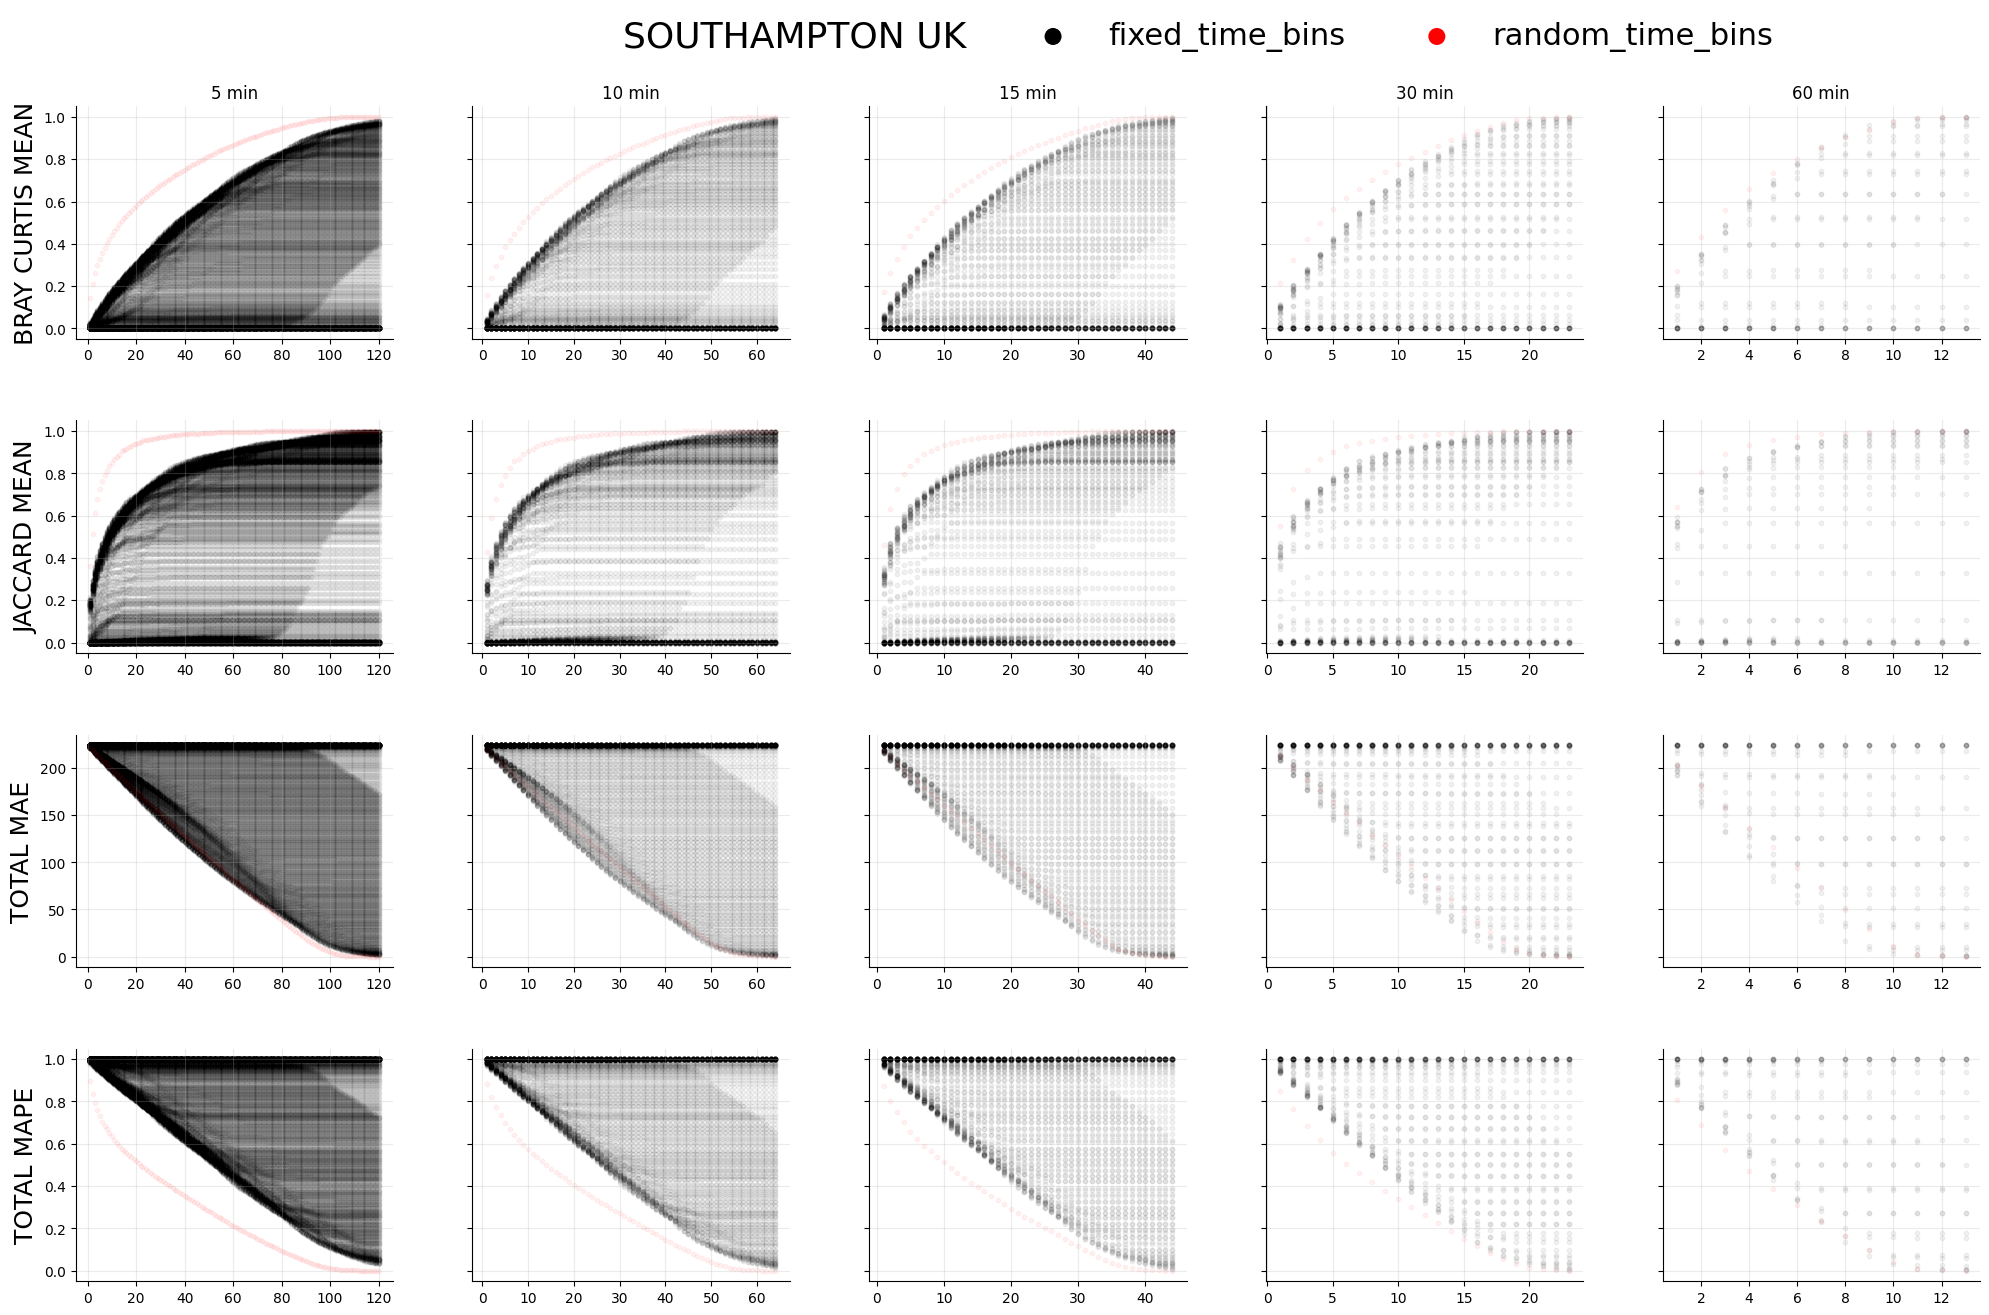

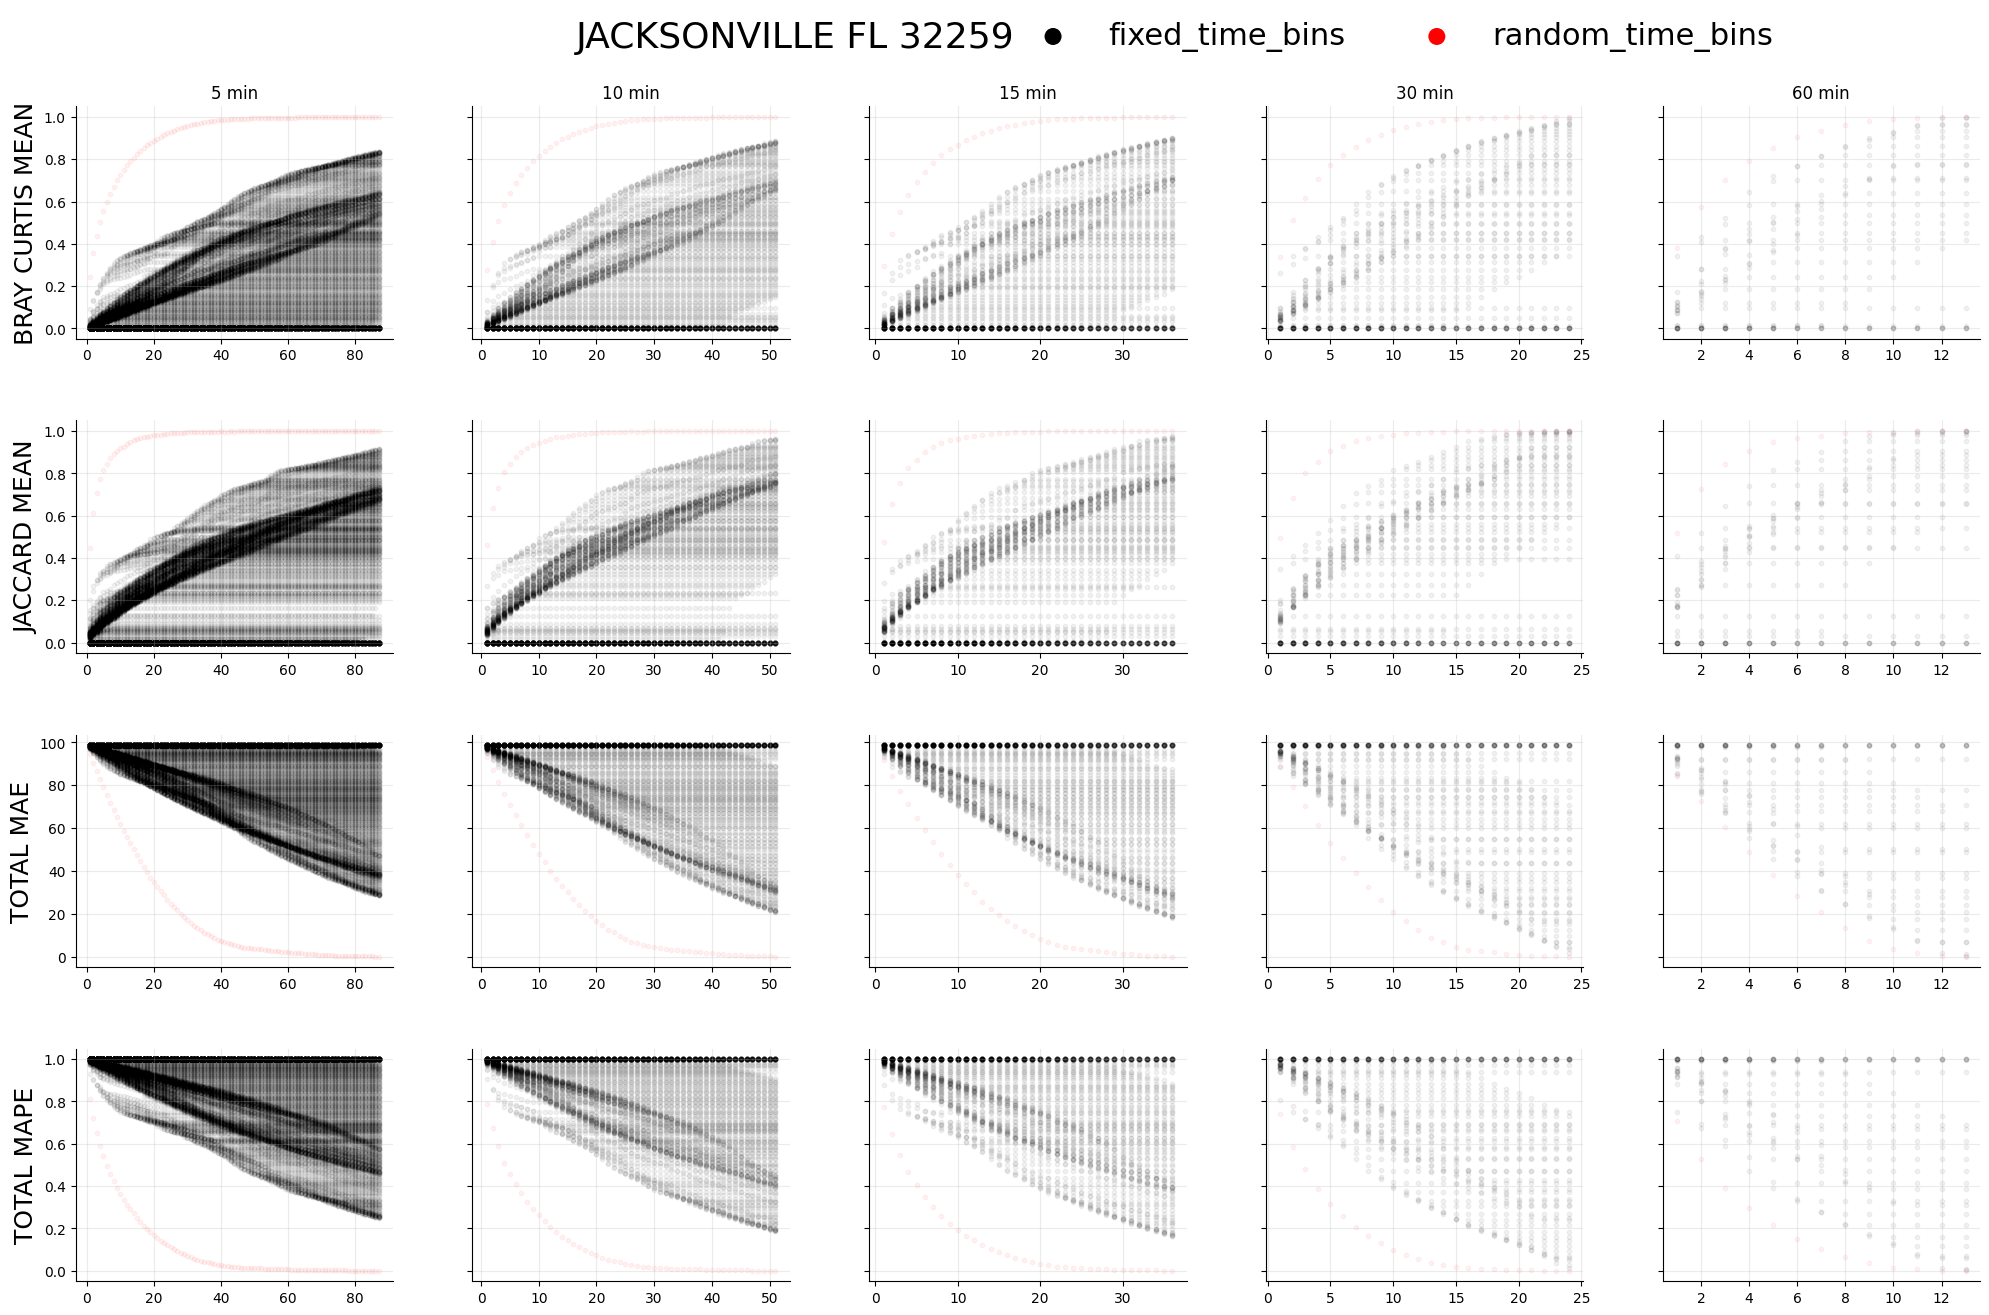

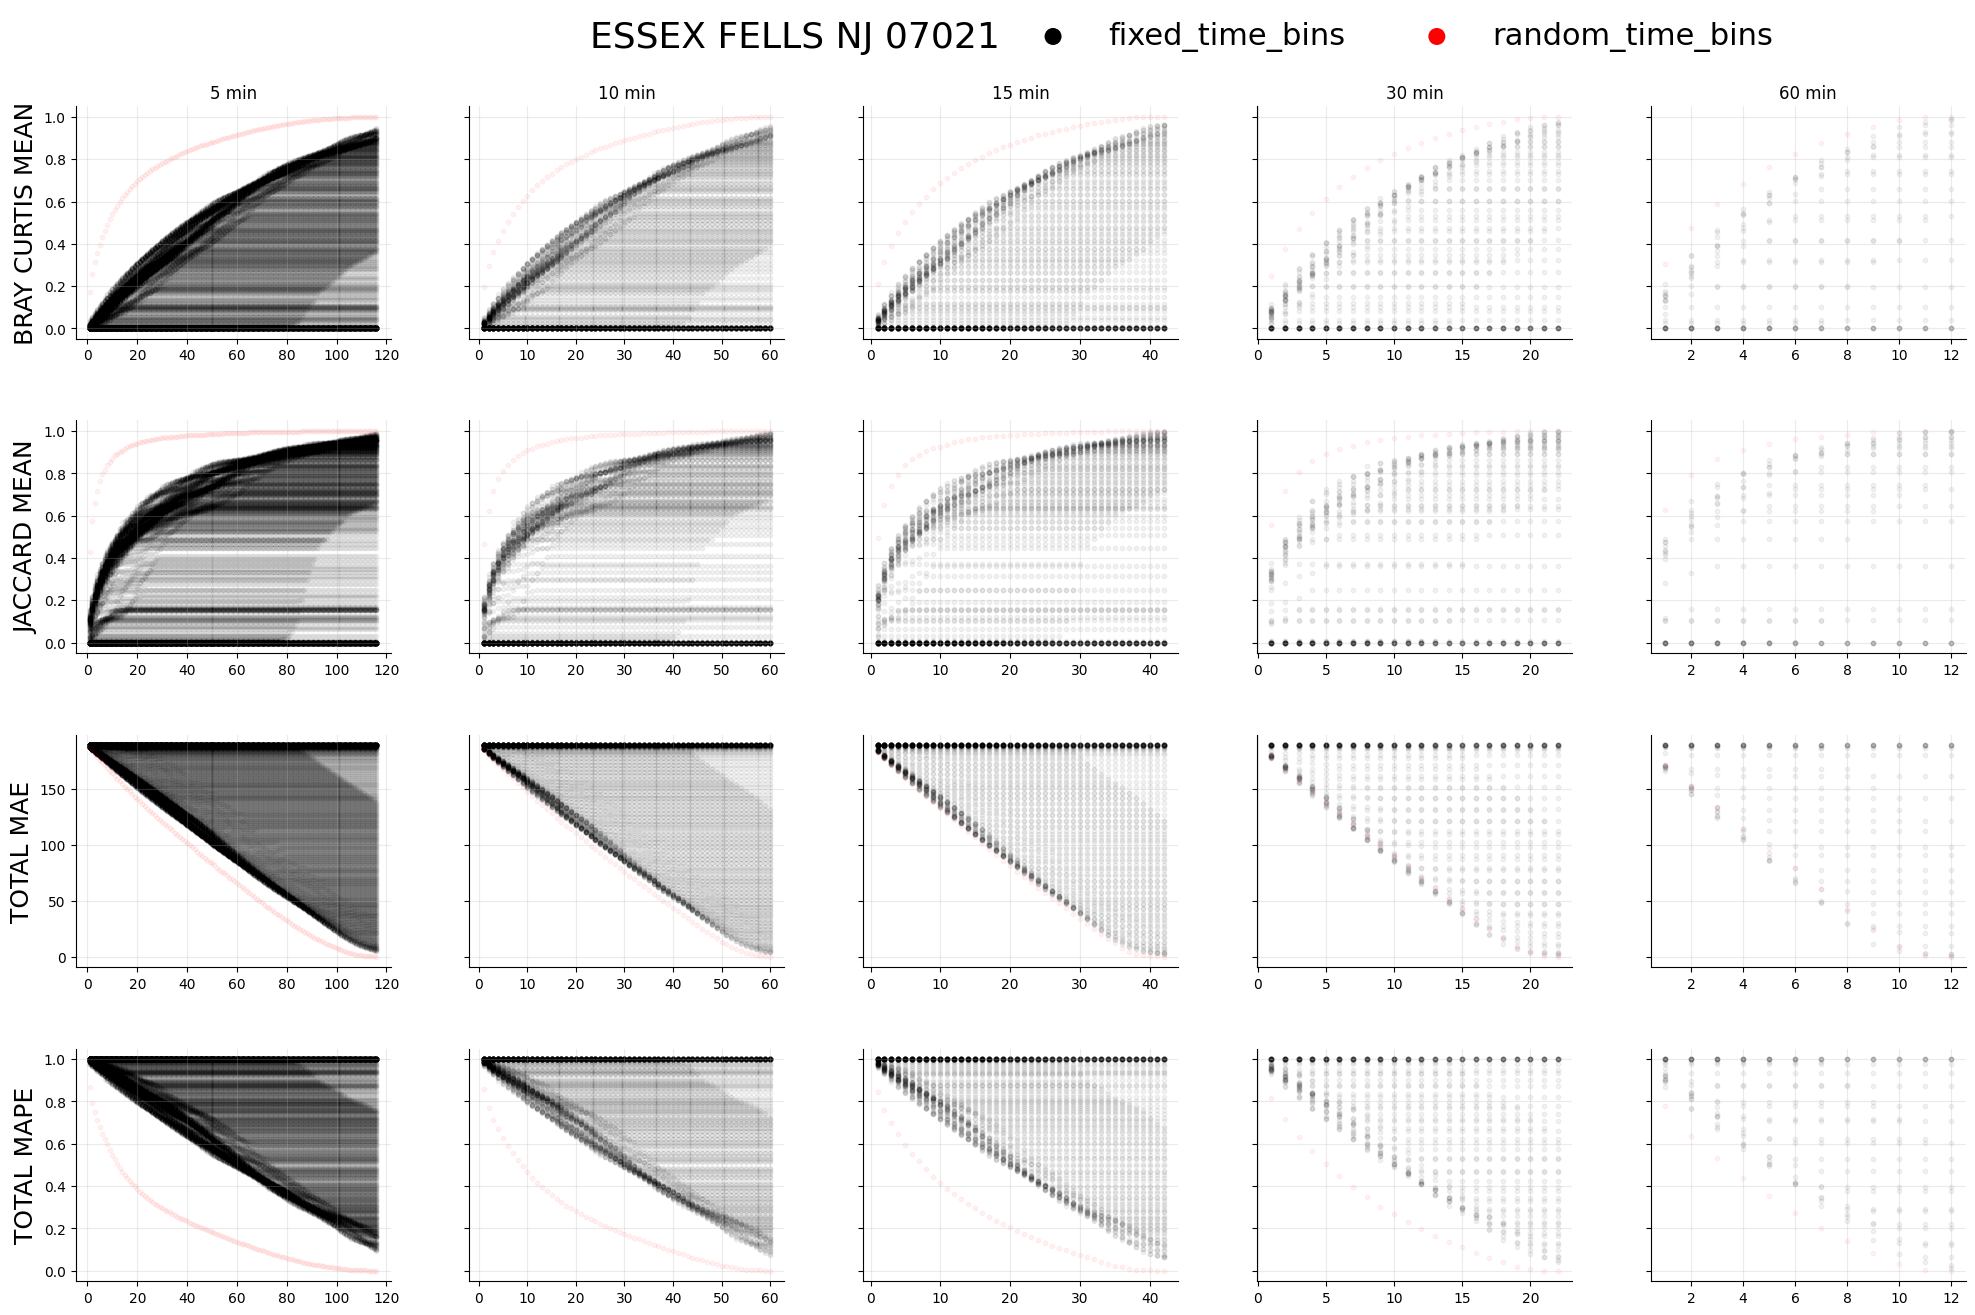

In [122]:
for site in pareto_results["site"].unique():
    plot_pareto_subplots_for_site(site, all_results, pareto_results, annotate_k=5)

In [ ]:
from matplotlib.ticker import ScalarFormatter

def _fmt_hhmm(minute: float) -> str:
    if pd.isna(minute):
        return ""
    m = int(minute)
    hh = m // 60
    mm = m % 60
    return f"{hh:02d}:{mm:02d}"


def plot_pareto_subplots_for_site(
    site: str,
    all_results: pd.DataFrame,
    pareto_results: pd.DataFrame,
    metrics: tuple[str, ...] = ("bray_curtis_mean", "jaccard_mean", "total_MAE", "total_MAPE"),
    effort_col: str = "windows_per_day",
    annotate_k: int = 4,
    alpha_all: float = 0.05,
    strategy_palette: list[str] | None = None,
):
    """
    5 rows (metrics) x 5 cols (window_minutes). One metric per row, one window_minutes per column.
    Plots all_results only, with hue = strategy (palette black/red).
    """
    if strategy_palette is None:
        strategy_palette = ["black", "red"]

    g = all_results[all_results["site"] == site].copy()
    pf = pareto_results[pareto_results["site"] == site].copy()

    if g.empty:
        raise ValueError(f"No rows for site={site!r} in all_results.")

    uniq_w = np.sort(g["window_minutes"].dropna().unique())[:5]
    n_w = len(uniq_w)
    if n_w == 0:
        raise ValueError(f"No window_minutes in all_results for site={site!r}.")

    uniq_strat = g["strategy"].dropna().unique()
    strat_to_color = {s: strategy_palette[i % len(strategy_palette)] for i, s in enumerate(uniq_strat)}

    fig, axes = plt.subplots(4, n_w, figsize=(4 * n_w, 13), sharey="row")
    if n_w == 1:
        axes = axes[:, np.newaxis]

    for i, metric in enumerate(metrics):
        for j, w in enumerate(uniq_w):
            ax = axes[i, j]
            gg = g[np.isfinite(g[effort_col]) & np.isfinite(g[metric])]
            if "window_minutes" in gg.columns:
                gg = gg[gg["window_minutes"] == w]

            if gg.empty:
                if i == 0:
                    ax.set_title(f"{int(w)} min")
                if i == 4:
                    ax.set_xlabel("Effort (avg event-bins processed per day)")
                if j == 0:
                    ax.set_ylabel(metric.replace("_", " ").capitalize(), fontsize=30)
                ax.grid(True, alpha=0.25)
                continue

            for strat in uniq_strat:
                mask = gg["strategy"] == strat
                if not mask.any():
                    continue
                sns.kdeplot(
                    data=gg.loc[mask],
                    x=effort_col,
                    y=metric,
                    ax=ax,
                    color=strat_to_color[strat],
                    label=strat,
                    fill=True,
                    alpha=0.3,
                    levels=5,
                )

            if i == 0:
                ax.set_title(f"{int(w)} min")
            if i == 4:
                ax.set_xlabel("Effort\n(Visits Processed)", fontsize=18)
            if j == 0:
                ax.set_ylabel(metric.replace("_", " ").upper(), fontsize=18)
            ax.grid(True, alpha=0.25)

        handles, labels = [], []
    for ax in axes.flat:
        h, l = ax.get_legend_handles_labels()
        handles.extend(h)
        labels.extend(l)
    uniq = dict(zip(labels, handles))
    fig.suptitle(f"{site.replace('_', ' ').upper()}", y=1, x=0.4, fontsize=26)  # left-aligned
    fig.legend(
        uniq.values(), uniq.keys(), loc="upper left", 
        bbox_to_anchor=(0.5, 1.0), ncol=2, frameon=False, 
        fontsize=26)
    sns.despine(top=True, right=True)
    plt.tight_layout()
    plt.subplots_adjust(hspace=0.35, wspace=0.25)
    plt.show()

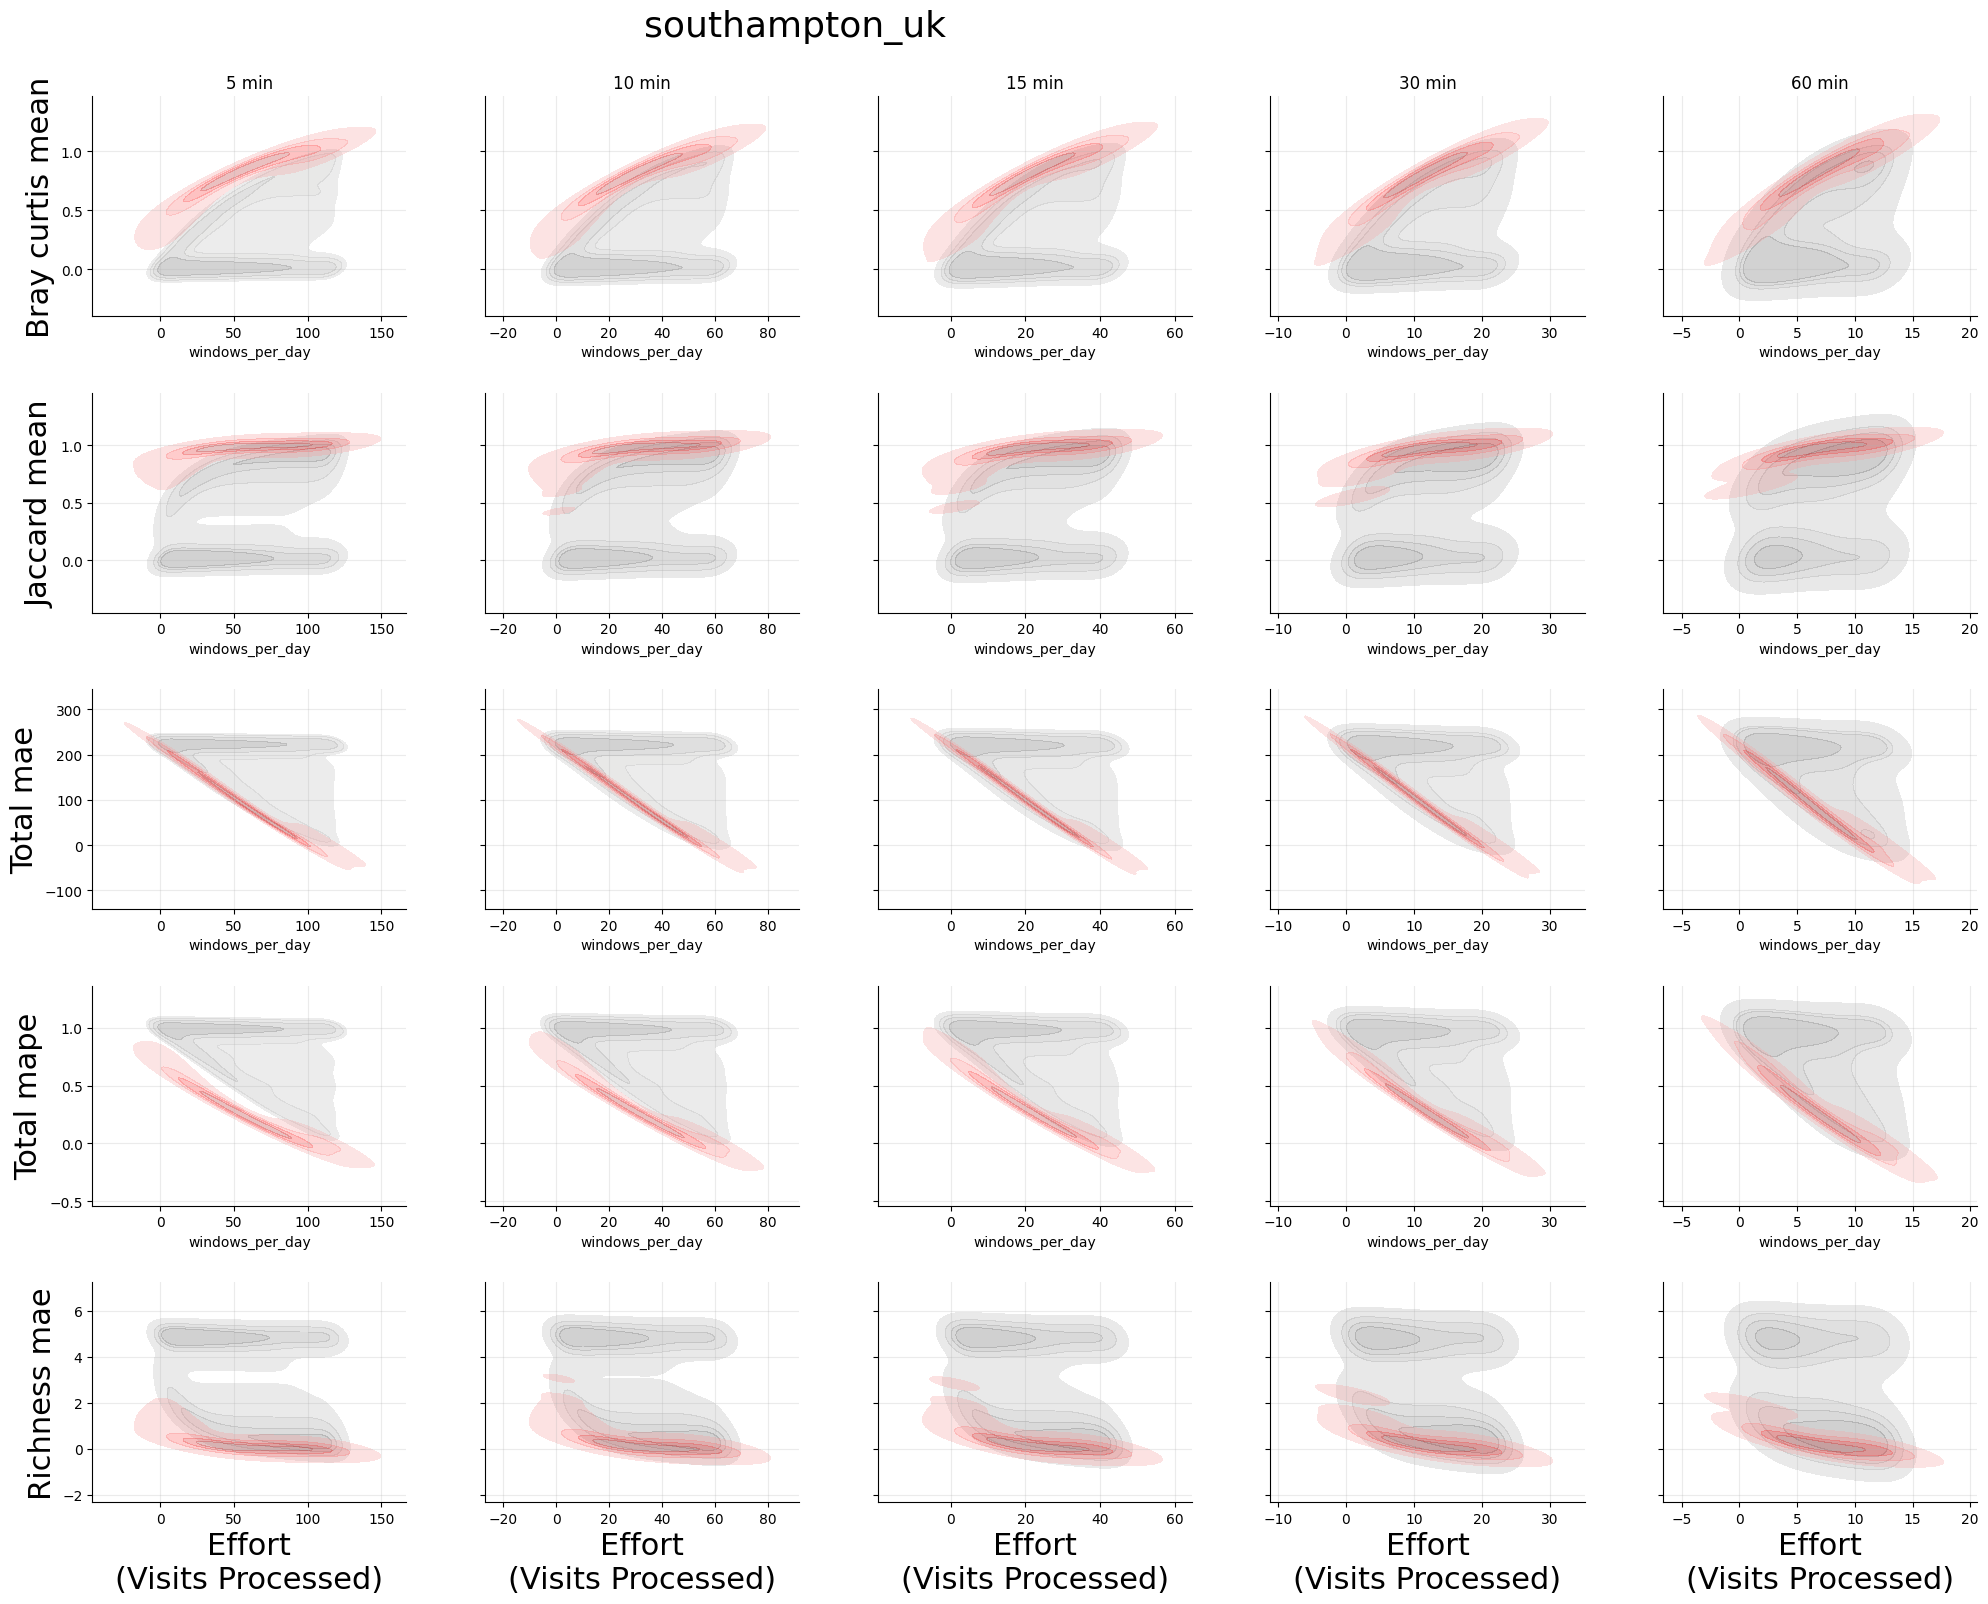

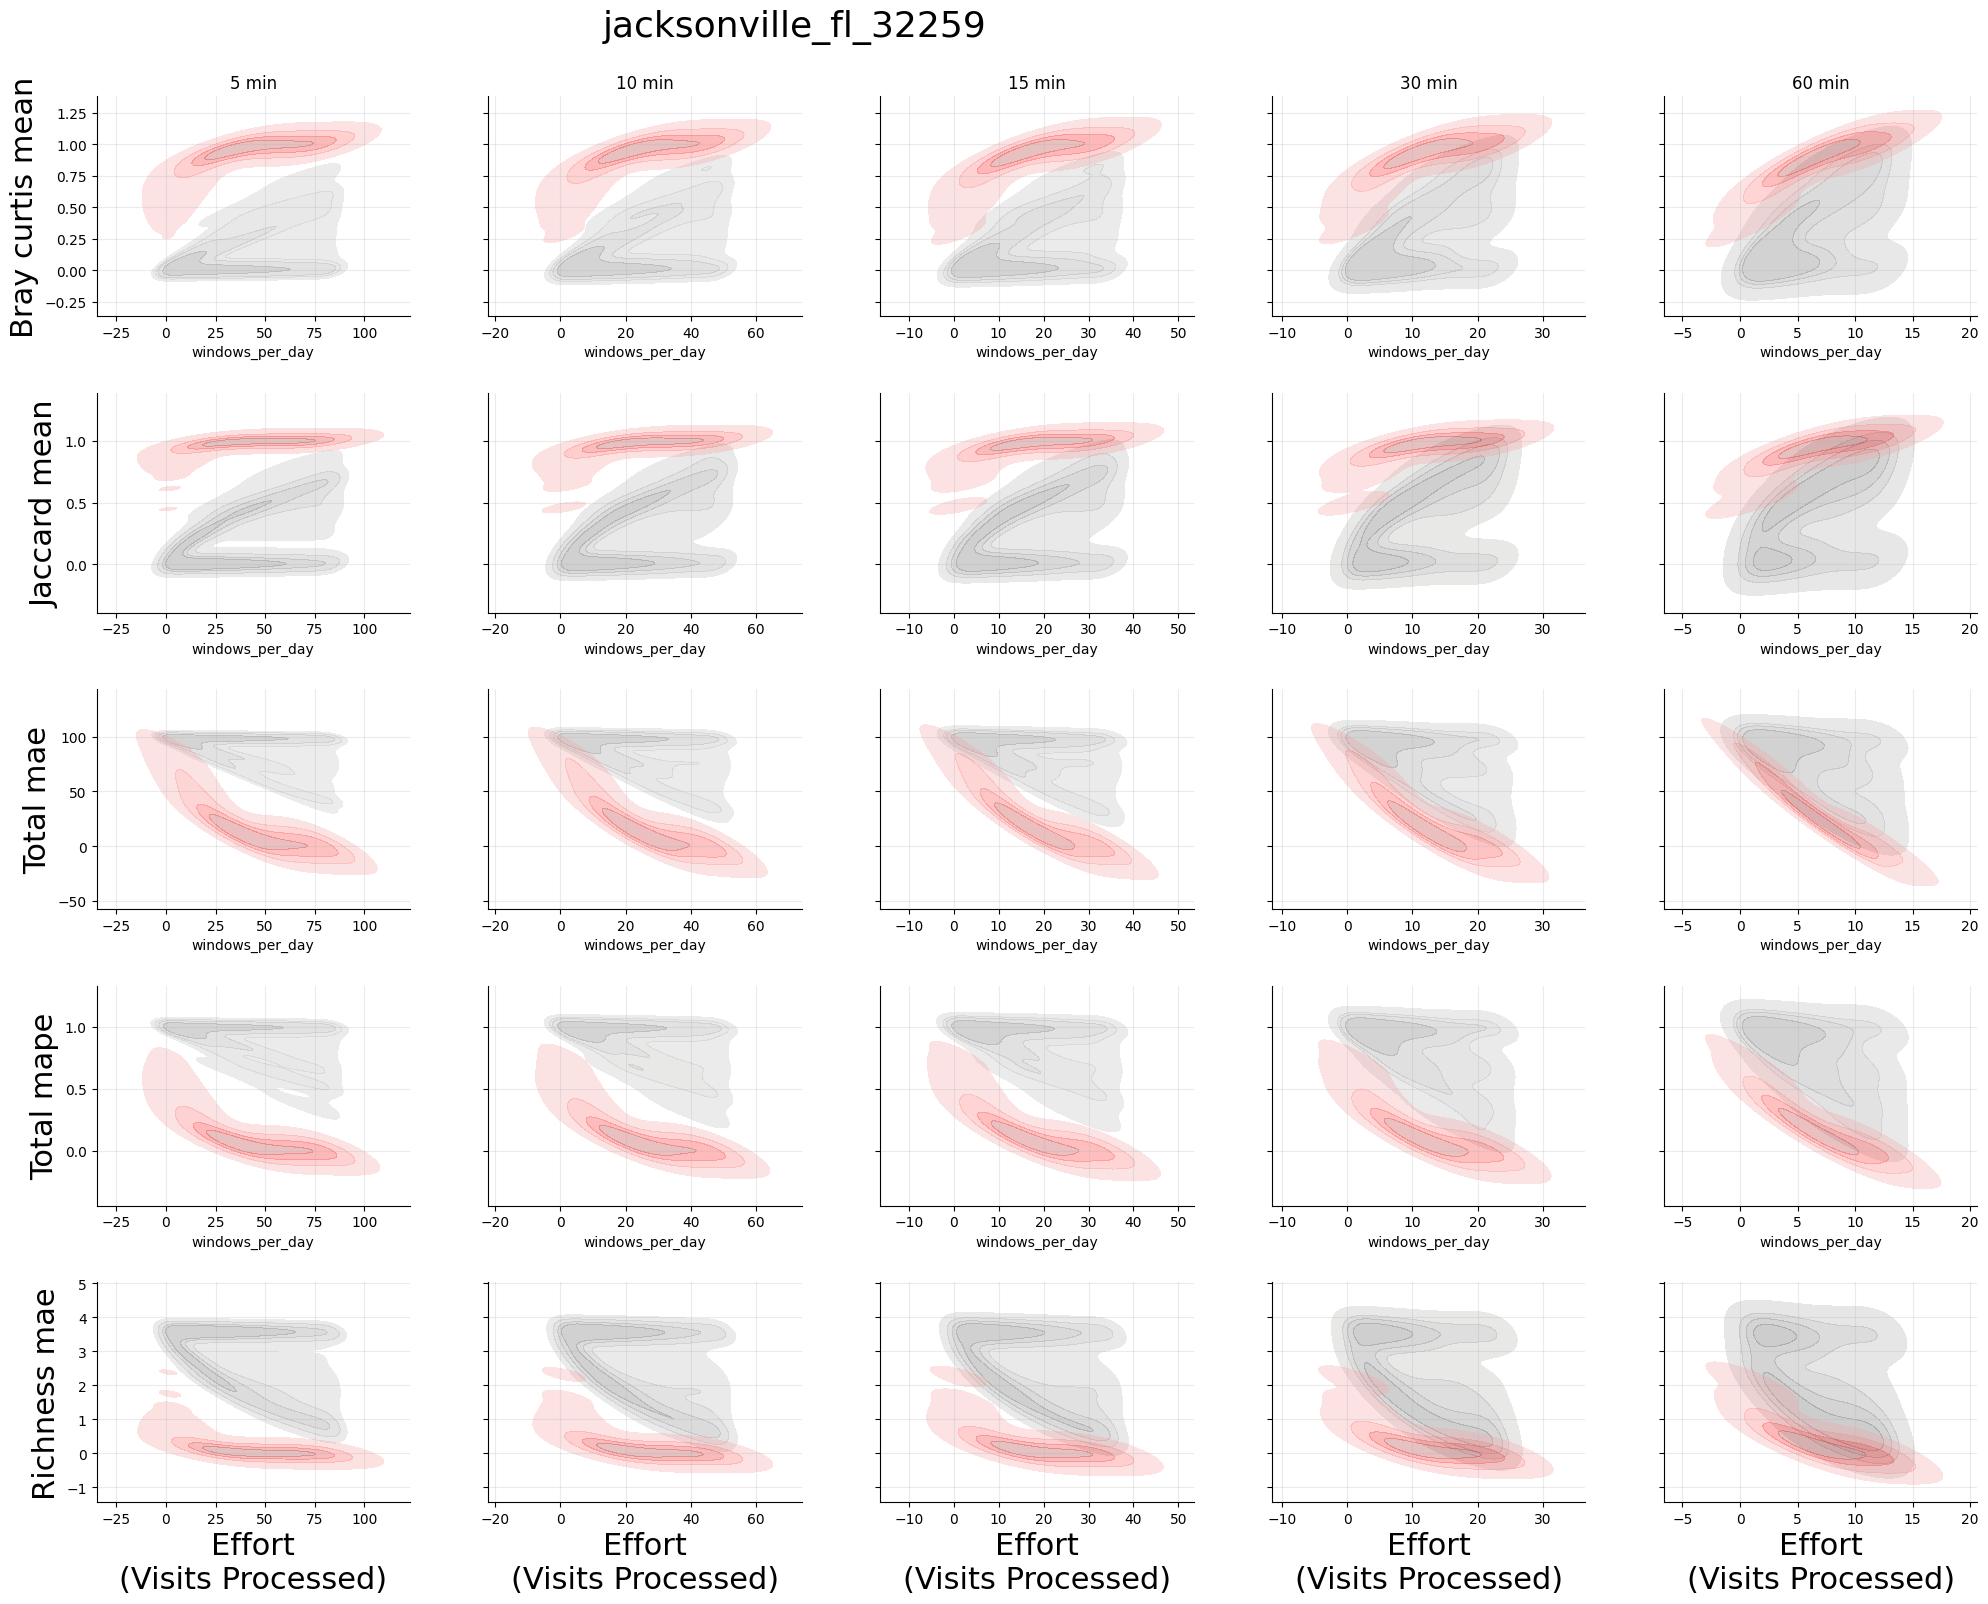

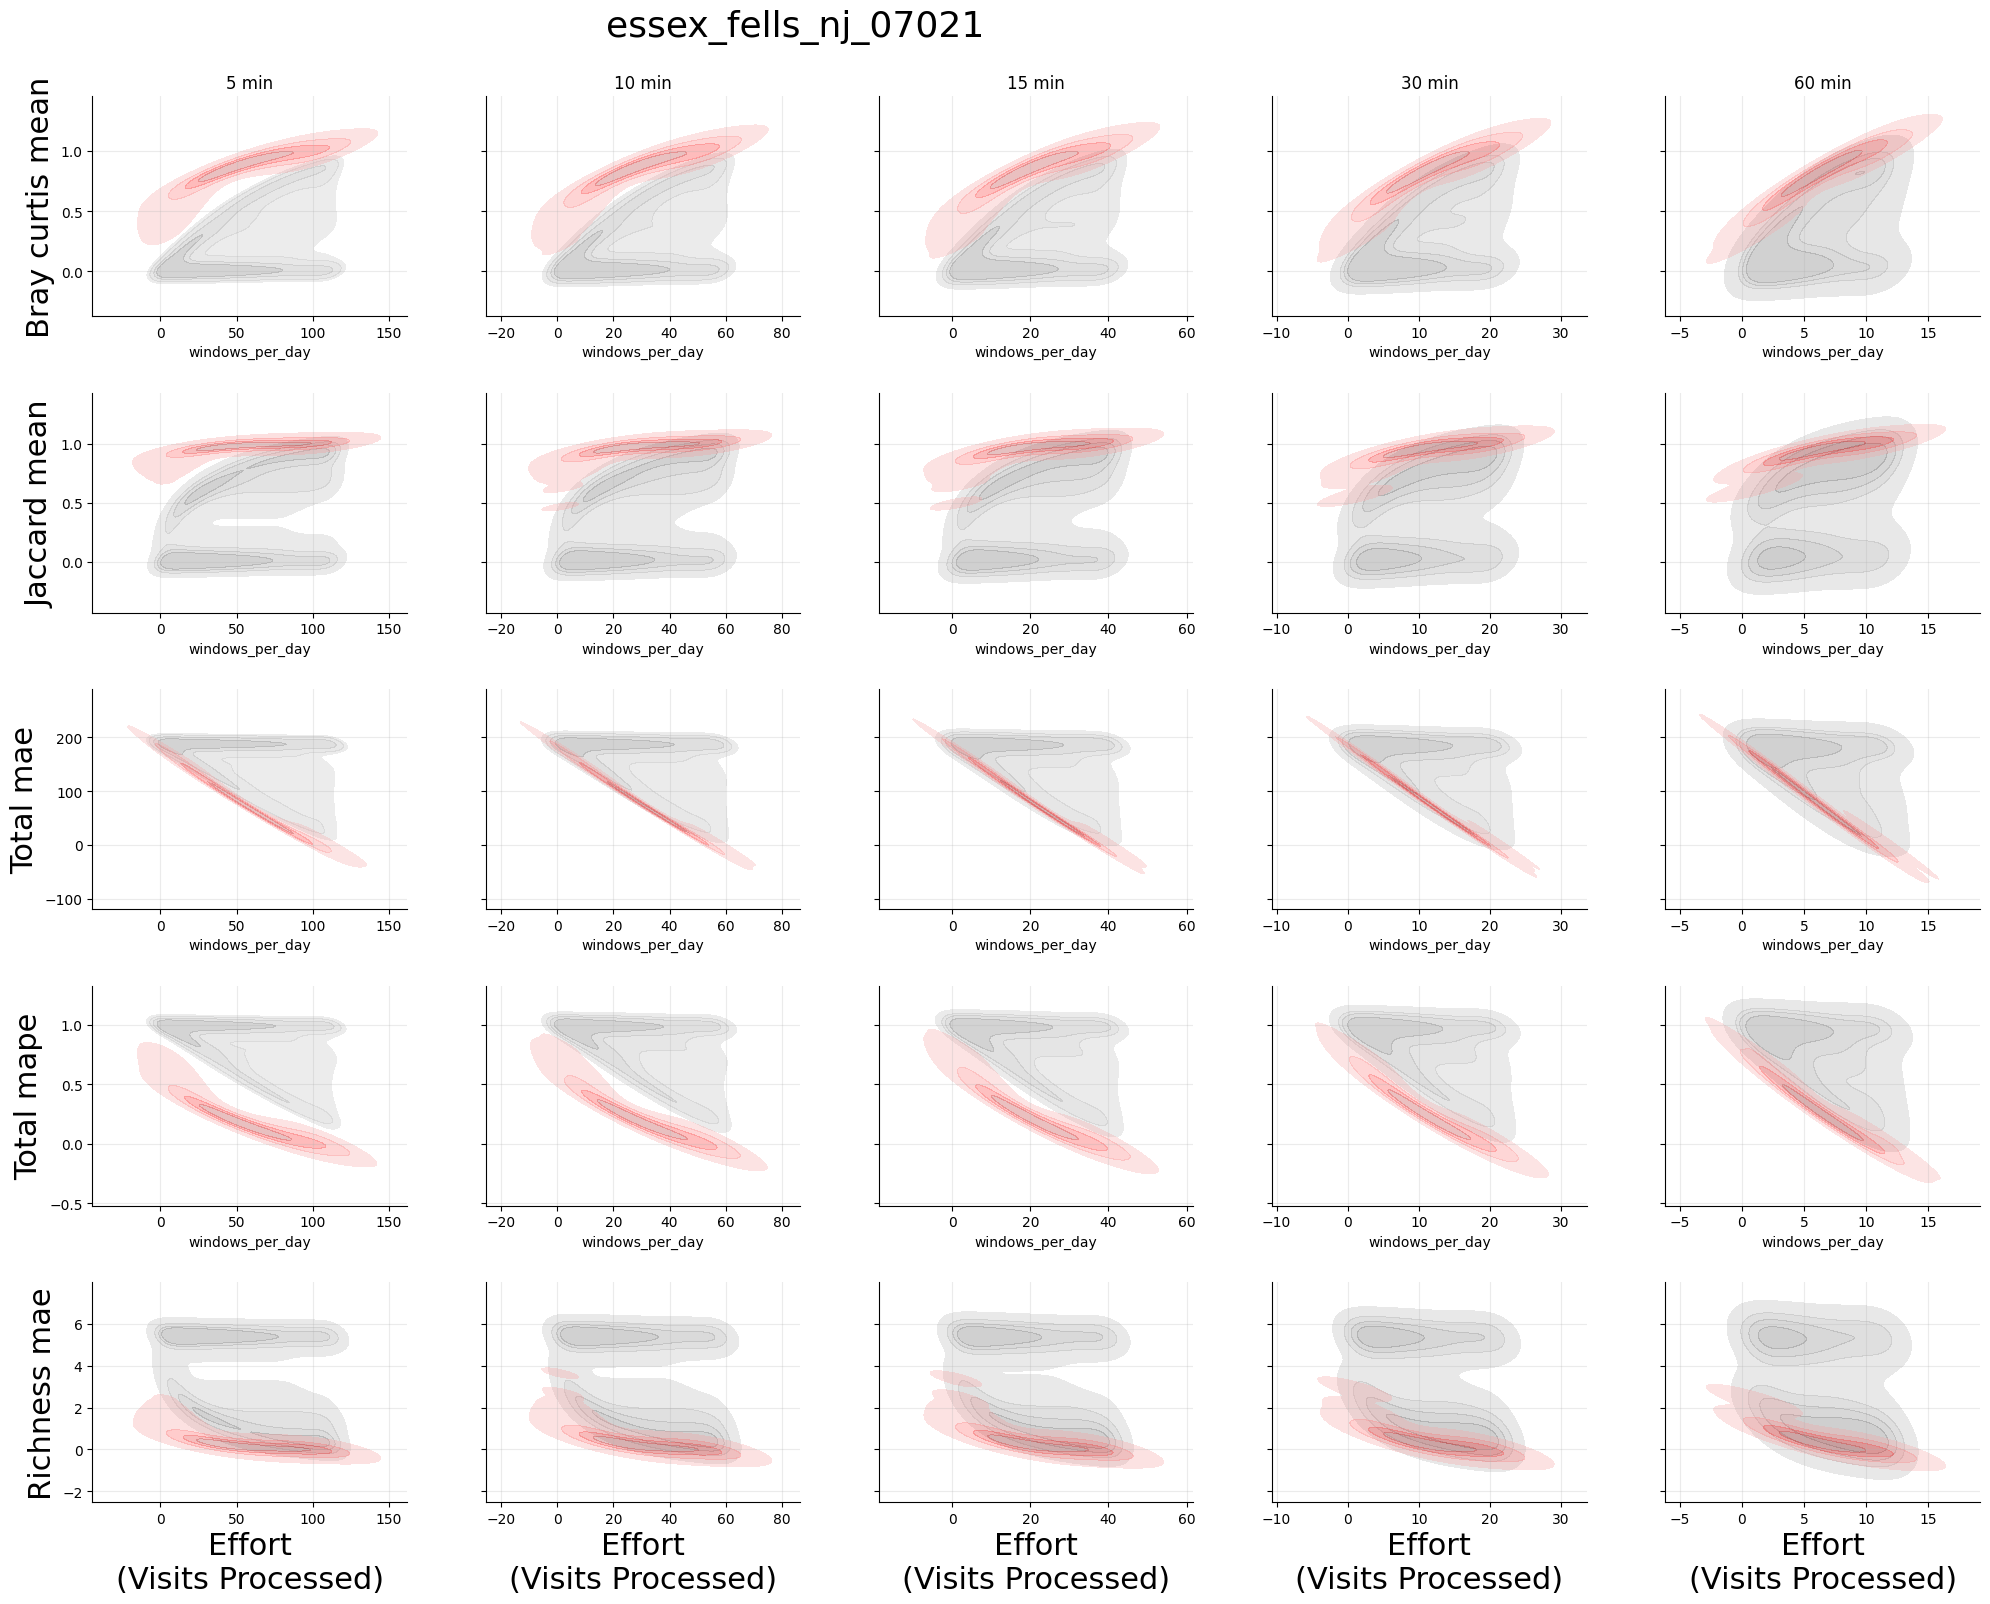

In [106]:
for site in pareto_results["site"].unique():
    plot_pareto_subplots_for_site(site, all_results, pareto_results, annotate_k=5)